## PREDICT FUTURE

## 2. Data Preparation
Prompt: Viết code python để lấy các dữ liệu để test các Hypotheses các biến phụ thuộc với biến độc lập

In [66]:
# Cài đặt và cập nhật thư viện vnstock
#!pip install tensorflow
#!pip install --upgrade vnstock
#!pip install ta
#!pip install Sequential
#!pip install backtesting
from vnstock import *  # Thư viện vnstock
from vnstock import Company
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from datetime import datetime
import seaborn as sns
# Correctly import or alias the 'stock' object from vnstock
import vnstock as stock # or from vvnstockmport stock

## Có thể gọi các class chi tiết trong thư viện thay vì sử dụng cấp cao nhất là Vnstock
from vnstock.explorer.vci import Listing, Quote, Company, Finance, Trading
## Bạn cũng có thể gọi các class trong theo vị trí chi tiết của nguồn dữ liệu
from vnstock.explorer.tcbs import Quote, Company, Finance, Trading, Screener


#!pip install scikit-learn matplotlib seaborn pandas numpy
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
#import model LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from sklearn.metrics import mean_absolute_percentage_error


In [67]:
import vnstock as stock
from vnstock import Screener  # Import the Screener class directly

screener_df = Screener().stock(params={"exchangeName": "HOSE,HNX,UPCOM"}, limit=3000)
# Call the 'stock' method directly from the Screener instance
screener_df

,ticker,exchange,industry,market_cap,roe,stock_rating,business_operation,business_model,financial_health,alpha,...,nim,price_vs_sma200,eps_ttm_growth1_year,eps_ttm_growth5_year,equity_mi,eps_recently,percent_price_vs_ma200,percent_price_vs_ma20,percent_price_vs_ma50,percent_price_vs_ma100
0,A32,UPCOM,Hàng cá nhân & Gia dụng,NaN,NaN,NaN,1.7,3.5,2.6,0.1,...,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAA,HSX,Hóa chất,3115.0,7.1,2.5,1.6,3.0,4.2,-0.1,...,NaN,None,-4.01,40.60,5388.0,941.0,1.7,0.7,-1.6,-1.0
2,AAH,UPCOM,Tài nguyên Cơ bản,424.0,1.5,2.5,1.1,NaN,4.2,0.0,...,NaN,None,NaN,NaN,1202.0,149.0,-14.3,-1.9,-8.6,-11.4
3,AAM,HSX,Thực phẩm và đồ uống,75.0,0.7,NaN,1.2,NaN,4.2,0.0,...,NaN,None,NaN,NaN,199.0,134.0,1.8,2.3,1.5,0.5
4,AAS,UPCOM,Dịch vụ tài chính,1945.0,6.3,2.4,3.8,2.8,3.6,-0.1,...,NaN,None,111.10,5000.00,2653.0,703.0,-14.5,-8.6,-23.0,-26.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617,XPH,UPCOM,Hàng cá nhân & Gia dụng,193.0,-1.1,NaN,1.1,NaN,4.2,0.3,...,NaN,None,NaN,NaN,145.0,-128.0,NaN,NaN,NaN,NaN
1618,YBC,UPCOM,Xây dựng và Vật liệu,106.0,-84.4,NaN,2.5,3.5,1.6,0.5,...,NaN,None,NaN,NaN,NaN,-1674.0,-24.9,-3.6,-10.4,-18.8
1619,YBM,HSX,Tài nguyên Cơ bản,199.0,11.0,NaN,2.3,3.7,2.6,0.2,...,NaN,None,56.72,49.36,206.0,1501.0,-5.2,-2.3,-3.1,-4.3
1620,YEG,HSX,Truyền thông,2254.0,7.9,2.3,1.5,3.0,4.8,-0.2,...,NaN,None,92.99,NaN,2057.0,705.0,-12.8,-4.9,-12.2,-13.0


In [68]:
screener1_df = screener_df[((screener_df['stock_rating'] >=3)& (screener_df['stock_rating'] <=10)) & (screener_df['dividend_yield'] > 1) & ((screener_df['pe'] > 14) & (screener_df['pe'] < 200)) & (screener_df['market_cap'] > 100)]
screener1_df

,ticker,exchange,industry,market_cap,roe,stock_rating,business_operation,business_model,financial_health,alpha,...,nim,price_vs_sma200,eps_ttm_growth1_year,eps_ttm_growth5_year,equity_mi,eps_recently,percent_price_vs_ma200,percent_price_vs_ma20,percent_price_vs_ma50,percent_price_vs_ma100
61,AST,HSX,Bán lẻ,3285.0,38.0,3.0,3.0,3.0,5.0,0.1,...,NaN,None,68.34,2458.20,645.0,5076.0,NaN,NaN,NaN,NaN
97,BGW,UPCOM,"Điện, nước & xăng dầu khí đốt",290.0,7.7,3.0,2.7,NaN,4.2,0.0,...,NaN,None,47.28,83.15,194.0,812.0,NaN,NaN,NaN,NaN
194,CCR,HNX,Hàng & Dịch vụ Công nghiệp,306.0,7.8,3.1,1.9,3.7,4.8,0.0,...,NaN,None,27.26,-14.02,277.0,872.0,NaN,NaN,NaN,NaN
327,DHG,HSX,Y tế,13441.0,21.8,3.0,3.0,4.0,4.8,0.0,...,NaN,None,10.36,24.94,3998.0,7022.0,3.9,-1.3,0.0,0.6
359,DNW,UPCOM,"Điện, nước & xăng dầu khí đốt",4200.0,11.7,3.0,3.3,3.0,4.4,0.0,...,NaN,None,-17.90,17.48,2288.0,2218.0,7.8,0.4,1.6,4.1
580,HJS,HNX,"Điện, nước & xăng dầu khí đốt",601.0,12.6,3.0,2.8,3.0,5.0,0.0,...,NaN,None,-28.69,-27.76,296.0,1795.0,NaN,NaN,NaN,NaN
662,ICT,HSX,Công nghệ Thông tin,792.0,5.0,3.1,1.2,3.0,4.6,0.2,...,NaN,None,-4.83,-71.97,640.0,1005.0,64.7,16.6,26.2,48.3
793,MCH,UPCOM,Thực phẩm và đồ uống,217263.0,44.3,3.4,4.0,3.0,4.0,0.0,...,NaN,None,-10.73,52.29,15982.0,6546.0,61.1,28.2,46.0,61.5
887,NLG,HSX,Bất động sản,17637.0,9.0,3.0,3.1,4.3,4.6,0.0,...,NaN,None,180.41,13.25,9816.0,1764.0,7.3,-3.3,-2.6,-3.1
985,PMC,HNX,Y tế,1597.0,29.9,3.1,3.1,3.4,5.0,0.3,...,NaN,None,-1.01,11.99,237.0,9023.0,63.2,30.3,49.2,61.2


In [69]:
screener2_df = screener1_df[['ticker','exchange', 'industry', 'roe','pe','pb', 'stock_rating', 'business_operation','business_model','financial_health','alpha','beta','dividend_yield']]
screener2_df

,ticker,exchange,industry,roe,pe,pb,stock_rating,business_operation,business_model,financial_health,alpha,beta,dividend_yield
61,AST,HSX,Bán lẻ,38.0,14.4,5.1,3.0,3.0,3.0,5.0,0.1,0.6,5.8
97,BGW,UPCOM,"Điện, nước & xăng dầu khí đốt",7.7,19.7,1.5,3.0,2.7,NaN,4.2,0.0,0.0,3.7
194,CCR,HNX,Hàng & Dịch vụ Công nghiệp,7.8,14.3,1.1,3.1,1.9,3.7,4.8,0.0,0.2,3.8
327,DHG,HSX,Y tế,21.8,14.6,3.4,3.0,3.0,4.0,4.8,0.0,0.4,10.2
359,DNW,UPCOM,"Điện, nước & xăng dầu khí đốt",11.7,15.8,1.8,3.0,3.3,3.0,4.4,0.0,0.1,5.1
580,HJS,HNX,"Điện, nước & xăng dầu khí đốt",12.6,15.9,2.0,3.0,2.8,3.0,5.0,0.0,-0.1,4.5
662,ICT,HSX,Công nghệ Thông tin,5.0,24.5,1.2,3.1,1.2,3.0,4.6,0.2,0.8,7.9
793,MCH,UPCOM,Thực phẩm và đồ uống,44.3,31.4,13.6,3.4,4.0,3.0,4.0,0.0,0.7,5.4
887,NLG,HSX,Bất động sản,9.0,20.6,1.8,3.0,3.1,4.3,4.6,0.0,1.2,1.5
985,PMC,HNX,Y tế,29.9,19.0,6.7,3.1,3.1,3.4,5.0,0.3,0.0,18.1


In [70]:
stock = Vnstock().stock(symbol='VN30F1M', source='VCI')

2025-11-12 13:01:13 - vnstock.common.data.data_explorer - INFO - Không phải là mã chứng khoán, thông tin công ty và tài chính không khả dụng.


In [71]:
df = stock.quote.history(
    symbol='GEX',
    start='2015-01-01',
    end=datetime.today().strftime('%Y-%m-%d')
)
df['time']=pd.to_datetime(df['time'],format="%m/%d/%Y")
df=df[df.high!=df.low]
df


,time,open,high,low,close,volume
0,2015-10-26,7.48,7.48,6.38,7.48,18200
2,2015-10-28,6.52,6.52,5.90,5.97,31900
3,2015-10-29,5.97,6.52,5.93,6.28,20300
4,2015-10-30,6.07,6.55,6.07,6.38,19500
5,2015-11-02,6.41,6.52,6.00,6.31,8200
...,...,...,...,...,...,...
2506,2025-11-06,45.30,45.30,43.05,45.10,10678200
2507,2025-11-07,44.90,45.90,43.25,43.95,10500200
2508,2025-11-10,43.10,43.80,40.90,40.90,14389700
2509,2025-11-11,41.15,43.25,39.95,43.25,13594400


In [72]:
vnindex_df= stock.quote.history(symbol='VNINDEX', start='2015-01-01', end=datetime.today().strftime('%Y-%m-%d'))
vnindex_df

,time,open,high,low,close,volume
0,2015-01-05,544.86,549.22,543.78,544.45,91834620
1,2015-01-06,539.08,550.11,538.82,549.66,94081890
2,2015-01-07,548.44,555.83,548.44,552.05,109445780
3,2015-01-08,553.49,556.80,552.15,553.47,73883040
4,2015-01-09,553.49,570.52,552.15,569.73,104203680
...,...,...,...,...,...,...
2708,2025-11-06,1656.67,1658.69,1638.12,1642.64,583918596
2709,2025-11-07,1636.24,1638.59,1595.34,1599.10,846874733
2710,2025-11-10,1598.02,1609.49,1580.54,1580.54,733963463
2711,2025-11-11,1585.32,1597.08,1578.42,1593.61,664598578


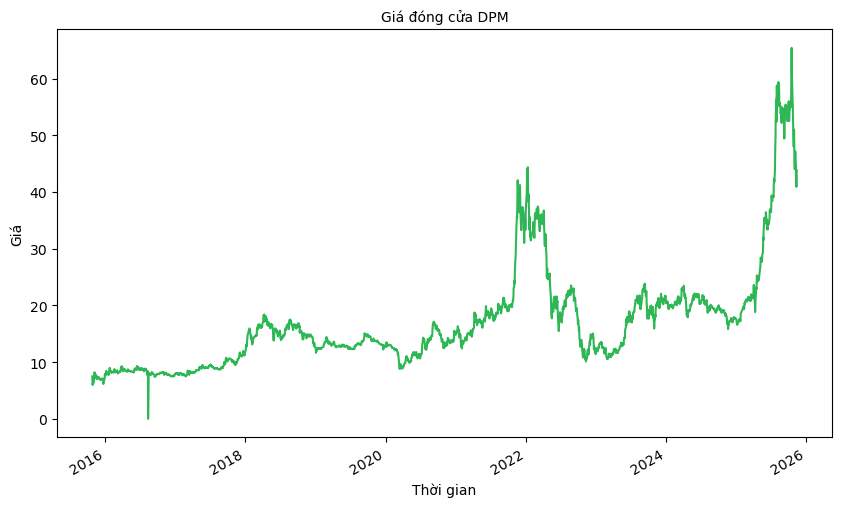

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Giá đóng cửa DPM'}, xlabel='Thời gian', ylabel='Giá'>)

In [73]:
df2=df.copy()
df2.set_index('time', inplace=True) # Thay 'date' bằng tên cột thời gian
# Mở help cho biểu đồ timeseries để xem tất cả các tuỳ chọn
df2['close'].viz.timeseries(figsize=(10, 6),
                           title='Giá đóng cửa DPM',
                           ylabel='Giá',
                           xlabel='Thời gian',
                           color_palette='vnstock',)

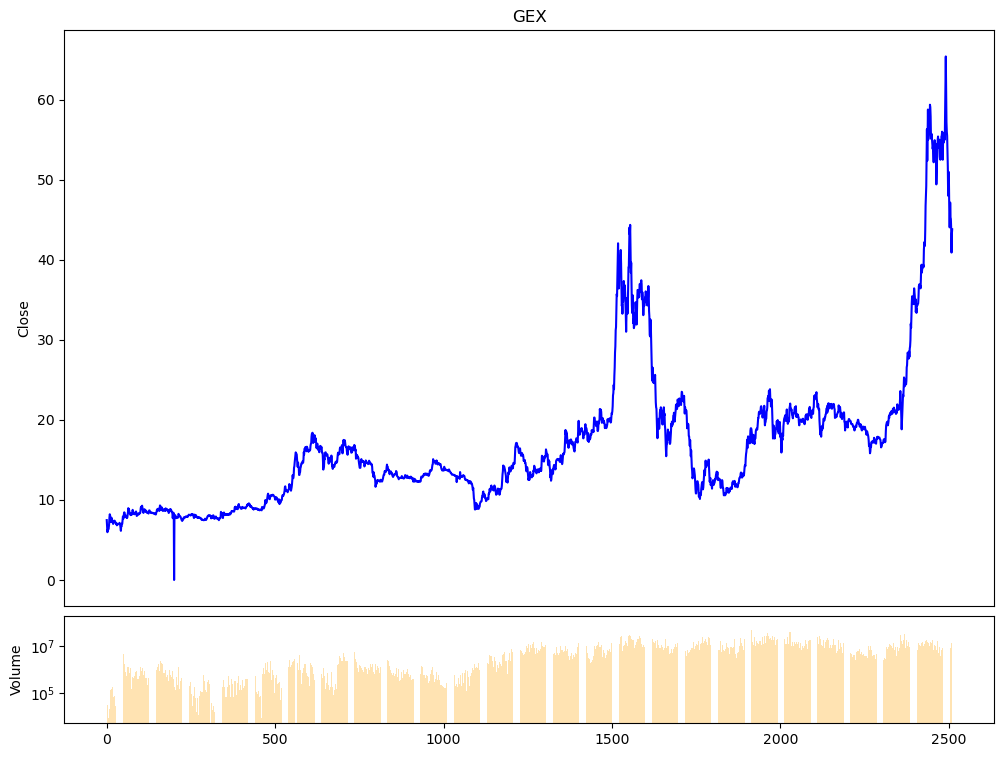

In [74]:
plt.figure(figsize=(12, 9))

top = plt.subplot2grid((12, 9), (0, 0), rowspan=10, colspan=9)
bottom = plt.subplot2grid((12, 9), (10, 0), rowspan=2, colspan=9)

# Vẽ đồ thị giá cổ phiếu trên trục y chính
top.plot(df.index, df['close'], color='blue')
top.set_title('GEX')
top.set_ylabel('Close')
top.axes.get_xaxis().set_visible(False)

# Vẽ đồ thị khối lượng giao dịch trên trục y phụ
bottom.bar(df.index, df['volume'], color='orange', alpha=0.3)

# Đặt nhãn cho trục y khối lượng
bottom.set_ylabel('Volume')

# Sử dụng log scale để hiển thị rõ ràng hơn nếu cần
bottom.set_yscale('log')  # Sử dụng log scale cho trục y của volume

plt.show()


In [75]:
print(df2.info())
print(df2.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2501 entries, 2015-10-26 to 2025-11-12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    2501 non-null   float64
 1   high    2501 non-null   float64
 2   low     2501 non-null   float64
 3   close   2501 non-null   float64
 4   volume  2501 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.2 KB
None
              open         high          low        close        volume
count  2501.000000  2501.000000  2501.000000  2501.000000  2.501000e+03
mean     17.067985    17.368665    16.723826    17.040584  6.859887e+06
std       9.579165     9.787925     9.275534     9.526323  8.403796e+06
min       5.790000     6.340000     5.520000     0.000000  8.200000e+03
25%      11.270000    11.440000    11.040000    11.250000  5.921400e+05
50%      14.660000    14.870000    14.470000    14.660000  4.015396e+06
75%      19.790000    20.100000    19.510000    19.78000

In [ ]:
import ta  # Thư viện ta để tính toán các chỉ báo
# Giả sử bạn đã tải dữ liệu `df` từ API
# Chọn các cột cần thiết
data_vn = df[['time','open', 'high', 'low', 'close', 'volume']].copy()



# 1. Tạo biến Stock High minus Low price (H-L)
data_vn['H-L'] = data_vn['high'] - data_vn['low']

# 2. Tạo biến Stock Close minus Open price (O-C)
data_vn['O-C'] = data_vn['close'] - data_vn['open']

# 3. Tạo biến Stock price’s seven days’ moving average (50 DAYS MA)
data_vn['SMA_50'] = data_vn['close'].rolling(window=50).mean()

# 4. Tạo biến Stock price’s fourteen days’ moving average (100 DAYS MA)
data_vn['SMA_100'] = data_vn['close'].rolling(window=100).mean()

# 5. Tạo biến Stock price’s twenty one days’ moving average (200 DAYS MA)
data_vn['SMA_200'] = data_vn['close'].rolling(window=200).mean()

# 6. Tạo biến Stock price’s standard deviation for the past seven days (200 DAYS STD DEV)
data_vn['20 DAYS STD DEV'] = data_vn['close'].rolling(window=200).std()

# Tính toán chỉ báo SMA và STD
data_vn['SMA_20'] = data_vn['close'].rolling(window=20).mean()
data_vn['STD'] = data_vn['close'].rolling(window=20).std()

# Tính toán Upper, Lower bands
data_vn['Upper'] = data_vn['SMA_20'] + (data_vn['STD'] * 2)
data_vn['Lower'] = data_vn['SMA_20'] - (data_vn['STD'] * 2)

# Tính toán RSI
data_vn['RSI'] = ta.momentum.RSIIndicator(data_vn['close'], window=14).rsi()

# Tín hiệu mua và bán
data_vn['Buy_Signal'] = (data_vn['close'] < data_vn['Lower']) & (data_vn['RSI'] < 30)
data_vn['Sell_Signal'] = (data_vn['close'] > data_vn['Upper']) & (data_vn['RSI'] > 70)

data_vn['returns'] = data_vn['close'].pct_change()
# Replace infinite values with NaN
data_vn.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN returns for mu and sigma calculation
returns_for_calc = data_vn['returns'].dropna()
mu = returns_for_calc.mean()
sigma = returns_for_calc.std()


# Tham số mô phỏng
num_simulations = 500
num_days = 30
last_price = data_vn['close'].iloc[-1]

# Calculate EMA and assign it to the 'EMA' column
data_vn['EMA'] = ta.trend.ema_indicator(data_vn['close'], window=12)
# Calculate SMA and assign it to the 'SMA' column
data_vn['SMA'] = ta.trend.sma_indicator(data_vn['close'], window=5)
# Calculate Bollinger Bands
bb = ta.volatility.BollingerBands(close=data_vn['close'], window=7, window_dev=1.2)
data_vn['BB_High'] = bb.bollinger_hband()
data_vn['BB_Low'] = bb.bollinger_lband()
data_vn['BB_Mid'] = bb.bollinger_mavg()

pd.options.mode.chained_assignment = None
def ma_signal(data_vn, current_candle, backcandles):
    df_slice = data_vn.reset_index().copy()
    # Rà hết vùng nến từ đầu đến cuối
    start = max(0, current_candle - backcandles)
    end = current_candle
    relevant_rows = df_slice.iloc[start:end]

    # Nếu tất cả SMA ớ dưới EMA, đề xuất lệnh bán
    if all(relevant_rows["SMA"] < relevant_rows["EMA"]):
        return 1  # bán
    # Nếu tất cả SMA ở trên EMA, đề xuất lệnh mua
    elif all(relevant_rows["SMA"] > relevant_rows["EMA"]):
        return 2  # mua
    else:
        return 0
data_vn.reset_index(inplace=True)
data_vn['MA_Signal'] = data_vn.apply(lambda row: ma_signal(data_vn, row.name, 2) , axis=1)
data_vn

Số lượng giá trị thiếu ban đầu:
index                0
time                 0
open                 0
high                 0
low                  0
close                0
volume               0
H-L                  0
O-C                  0
SMA_50              49
SMA_100             99
SMA_200            199
20 DAYS STD DEV    199
SMA_20              19
STD                 19
Upper               19
Lower               19
RSI                 13
Buy_Signal           0
Sell_Signal          0
returns              2
EMA                 11
SMA                  4
BB_High              6
BB_Low               6
BB_Mid               6
MA_Signal            0
dtype: int64

Số lượng giá trị thiếu sau khi thay thế:
index              0
time               0
open               0
high               0
low                0
close              0
volume             0
H-L                0
O-C                0
SMA_50             0
SMA_100            0
SMA_200            0
20 DAYS STD DEV    0
SMA_20             

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10152\954498021.py:91: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [77]:
def bol_signal(data_vn, current_candle):
    if data_vn.close[current_candle]>=data_vn['BB_High'][current_candle]: # Changed 'BBU_7_1.2' to 'BB_High'
        return 1 #bán
    elif data_vn.close[current_candle]<=data_vn['BB_Low'][current_candle]: # Changed 'BBL_7_1.2' to 'BB_Low'
        return 2 #mua
data_vn['Bol_Signal'] = data_vn.apply(lambda row: bol_signal(data_vn, row.name), axis=1)

In [78]:
data_vn[data_vn["Bol_Signal"]!=0]

,index,time,open,high,low,close,volume,H-L,O-C,SMA_50,...,Buy_Signal,Sell_Signal,returns,EMA,SMA,BB_High,BB_Low,BB_Mid,MA_Signal,Bol_Signal
0,0,2015-10-26,7.48,7.48,6.38,7.48,18200,1.10,0.00,7.1192,...,False,False,-0.201872,7.294966,6.484,7.113512,6.000773,6.557143,1,1.0
1,2,2015-10-28,6.52,6.52,5.90,5.97,31900,0.62,-0.55,7.1192,...,False,False,-0.201872,7.294966,6.484,7.113512,6.000773,6.557143,0,2.0
2,3,2015-10-29,5.97,6.52,5.93,6.28,20300,0.59,0.31,7.1192,...,False,False,0.051926,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN
3,4,2015-10-30,6.07,6.55,6.07,6.38,19500,0.48,0.31,7.1192,...,False,False,0.015924,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN
4,5,2015-11-02,6.41,6.52,6.00,6.31,8200,0.52,-0.10,7.1192,...,False,False,-0.010972,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2496,2506,2025-11-06,45.30,45.30,43.05,45.10,10678200,2.25,-0.20,53.4818,...,False,False,-0.004415,48.502764,45.140,48.974255,43.582888,46.278571,1,NaN
2497,2507,2025-11-07,44.90,45.90,43.25,43.95,10500200,2.65,-0.95,53.2976,...,False,False,-0.025499,47.802339,45.120,46.888549,43.682880,45.285714,1,NaN
2498,2508,2025-11-10,43.10,43.80,40.90,40.90,14389700,2.90,-2.20,53.0168,...,False,False,-0.069397,46.740440,44.480,46.468253,42.260319,44.364286,1,2.0
2499,2509,2025-11-11,41.15,43.25,39.95,43.25,13594400,3.30,2.10,52.8086,...,False,False,0.057457,46.203450,43.700,46.404756,42.095244,44.250000,1,NaN


In [79]:
import numpy as np
def pointpos(x):
    if x['MA_Signal']==2 or  x['Bol_Signal']==2:
        return x['low']-1e-3
    elif x['MA_Signal']==1 or x['Bol_Signal']==1:
        return x['high']+1e-3
    else:
        return np.nan

data_vn['pointpos'] = data_vn.apply(lambda row: pointpos(row), axis=1)

In [80]:
print(data_vn.info())
print(data_vn.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   index            2501 non-null   int64         
 1   time             2501 non-null   datetime64[ns]
 2   open             2501 non-null   float64       
 3   high             2501 non-null   float64       
 4   low              2501 non-null   float64       
 5   close            2501 non-null   float64       
 6   volume           2501 non-null   int64         
 7   H-L              2501 non-null   float64       
 8   O-C              2501 non-null   float64       
 9   SMA_50           2501 non-null   float64       
 10  SMA_100          2501 non-null   float64       
 11  SMA_200          2501 non-null   float64       
 12  20 DAYS STD DEV  2501 non-null   float64       
 13  SMA_20           2501 non-null   float64       
 14  STD              2501 non-null   float64

In [ ]:
# Kiểm tra dữ liệu ban đầu
print("Số lượng giá trị thiếu ban đầu:")
print(data_vn.isnull().sum())


# Backward fill: Điền giá trị gần nhất từ dưới lên (nếu vẫn còn missing)
data_vn.fillna(method='bfill', inplace=True)


# Kiểm tra lại dữ liệu sau khi xử lý
print("\nSố lượng giá trị thiếu sau khi thay thế:")
print(data_vn.isnull().sum())

# Hiển thị DataFrame sau khi loại bỏ
print("DataFrame sau khi loại bỏ các cột high, low và open:")
print(data_vn.head())

In [81]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

st = 1
dfpl = data_vn[st : st + 35]
fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl.index,
            open=dfpl["open"],
            high=dfpl["high"],
            low=dfpl["low"],
            close=dfpl["close"],
        ),
        go.Scatter(
            x=dfpl.index,
            y=dfpl["BB_Low"],  # Changed 'BBL_7_1.2' to 'BB_Low'
            line=dict(color="green", width=1),
            name="BBL",
        ),
        go.Scatter(
            x=dfpl.index,
            y=dfpl["BB_High"],  # Changed 'BBU_7_1.2' to 'BB_High'
            line=dict(color="green", width=1),
            name="BBU",
        ),
        go.Scatter(
            x=dfpl.index, y=dfpl["SMA"], line=dict(color="black", width=1), name="SMA"
        ),
        go.Scatter(
            x=dfpl.index, y=dfpl["EMA"], line=dict(color="blue", width=1), name="EMA"
        ),
    ]
)

fig.add_scatter(
    x=dfpl.index,
    y=dfpl["pointpos"],
    mode="markers",
    marker=dict(size=5, color="MediumPurple"),
    name="entry",
)

fig.show()

In [82]:
from backtesting import Strategy
df_trade = data_vn
df_trade.index=pd.to_datetime(df['time'],format='%Y/%m/%d')
df_trade = df_trade.rename(columns={'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'})
class MyStrat(Strategy):

    def init(self):
        pass
    def next(self):
        if self.data.MA_Signal == 2 or self.data.Bol_Signal == 2:
            if len(self.trades)== 0:
                self.buy()
        if self.data.MA_Signal== 1 or self.data.Bol_Signal == 1:
            self.position.close()
bt = Backtest(df_trade, MyStrat, cash=10000000)
bt.run()

Backtest.run:   0%|          | 0/2500 [00:00<?, ?bar/s]

c:\Users\ADMIN\anaconda3\Lib\site-packages\backtesting\_stats.py:157: RuntimeWarning:

divide by zero encountered in divide

c:\Users\ADMIN\anaconda3\Lib\site-packages\backtesting\_stats.py:157: RuntimeWarning:

divide by zero encountered in log



Start                     2015-10-26 00:00:00
End                       2025-11-12 00:00:00
Duration                   3670 days 00:00:00
Exposure Time [%]                     67.2531
Equity Final [$]                  12159384.37
Equity Peak [$]                   24326337.96
Return [%]                           21.59384
Buy & Hold Return [%]                485.5615
Return (Ann.) [%]                     1.98955
Volatility (Ann.) [%]                34.84161
CAGR [%]                              1.35156
Sharpe Ratio                           0.0571
Sortino Ratio                         0.08929
Calmar Ratio                          0.02841
Alpha [%]                                 NaN
Beta                                      NaN
Max. Drawdown [%]                   -70.04101
Avg. Drawdown [%]                    -9.40023
Max. Drawdown Duration     2851 days 00:00:00
Avg. Drawdown Duration      201 days 00:00:00
# Trades                                  412
Win Rate [%]                      

In [83]:
bt.plot()

GridPlot(id='p2035', ...)

Beta của cổ phiếu: 1.2829
Lợi suất kỳ vọng của cổ phiếu (E(Ri)) theo CAPM: -0.0079


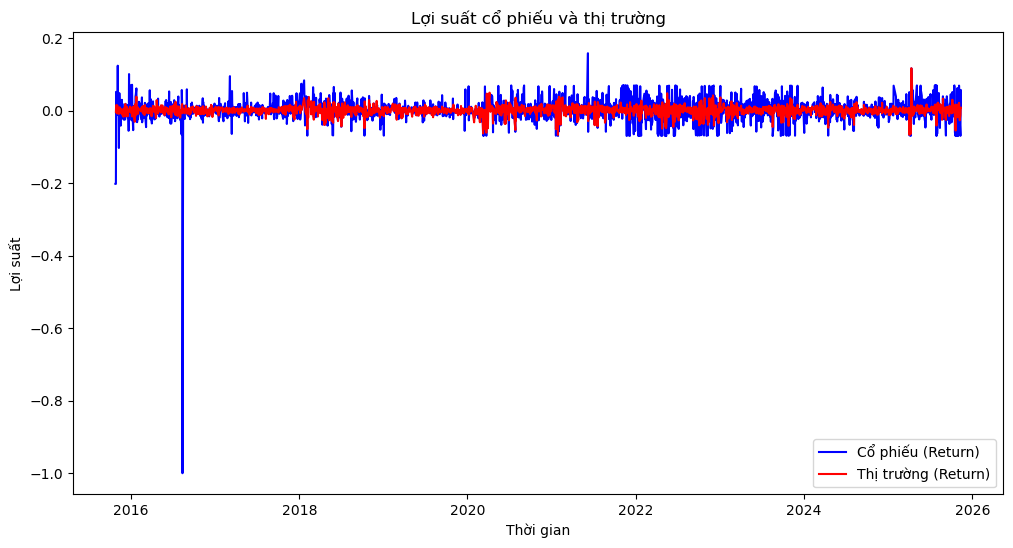

In [84]:
# Giả sử bạn đã có dữ liệu cổ phiếu và VN-Index trong data_vn và vnindex_df
# Cắt ngắn dữ liệu để có cùng thời gian
common_dates = data_vn['time'].isin(vnindex_df['time'])
data_vn = data_vn[common_dates]

# Use .loc to filter vnindex_df based on common dates in 'time' column
vnindex_df = vnindex_df.loc[vnindex_df['time'].isin(data_vn['time'])]

# Tính lợi suất thị trường (ví dụ: VN-Index)
# Giả sử data_market chứa dữ liệu của thị trường (có lợi suất tương tự cổ phiếu)
vnindex_df = vnindex_df[['time', 'close']].copy()  # Giả sử sử dụng cùng dữ liệu cho cổ phiếu và thị trường
vnindex_df['Returns'] = vnindex_df['close'].pct_change()

# Tính toán Beta (hệ số Beta của cổ phiếu)
# Beta = Covariance(Return_stock, Return_market) / Variance(Return_market)
cov_matrix = np.cov(data_vn['returns'][1:], vnindex_df['Returns'][1:])
beta = cov_matrix[0, 1] / cov_matrix[1, 1]

# Lợi suất không rủi ro (Risk-Free rate) - giả sử là 0.03 (3%)
Rf = 0.03

# Lợi suất kỳ vọng của thị trường (E(Rm)) - có thể lấy từ trung bình lợi suất của thị trường
E_Rm = np.mean(vnindex_df['Returns'][1:])

# Tính lợi suất kỳ vọng của cổ phiếu (E(Ri)) theo CAPM
E_Ri = Rf + beta * (E_Rm - Rf)

# In kết quả
print(f"Beta của cổ phiếu: {beta:.4f}")
print(f"Lợi suất kỳ vọng của cổ phiếu (E(Ri)) theo CAPM: {E_Ri:.4f}")

# Vẽ biểu đồ lợi suất của cổ phiếu và thị trường
plt.figure(figsize=(12, 6))
plt.plot(data_vn['time'], data_vn['returns'], label="Cổ phiếu (Return)", color="blue")
plt.plot(vnindex_df['time'], vnindex_df['Returns'], label="Thị trường (Return)", color="red")
plt.xlabel("Thời gian")
plt.ylabel("Lợi suất")
plt.title("Lợi suất cổ phiếu và thị trường")
plt.legend()
plt.show()

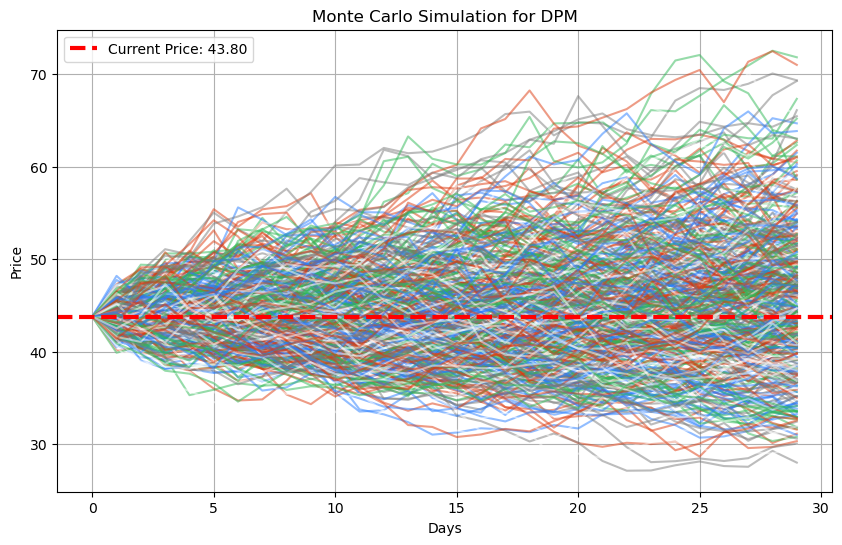

Expected Price after 30 days: 45.91
VaR (95% Confidence): 33.00


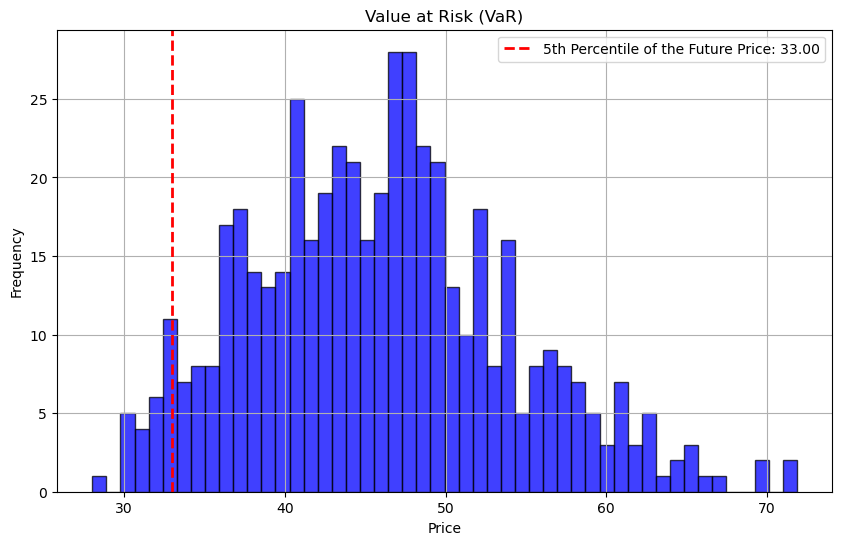

VaR at 95% confidence interval is: 10.80 USD


In [85]:
# Chạy mô phỏng Monte Carlo
simulation_df = np.zeros((num_days, num_simulations))
for i in range(num_simulations):
    price_series = [last_price]
    for j in range(1, num_days):
        next_price = price_series[-1] * np.exp(np.random.normal(mu, sigma))  # Công thức mô phỏng giá
        price_series.append(next_price)
    simulation_df[:, i] = price_series

# Vẽ biểu đồ mô phỏng với mỗi đường một màu
plt.figure(figsize=(10, 6))
for i in range(num_simulations):
    plt.plot(simulation_df[:, i], alpha=0.5, linewidth=1.5)  # Tăng linewidth lên 1.5

# Thêm đường giá hiện tại màu đỏ
plt.axhline(y=last_price, color='red', linestyle='--', linewidth=3, label=f'Current Price: {last_price:.2f}')

# Thêm chú thích
plt.title(f'Monte Carlo Simulation for DPM')  # Dùng 'symbol' đã định nghĩa
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

# Thống kê kết quả
final_prices = simulation_df[-1, :]
expected_price = np.mean(final_prices)
var_95 = np.percentile(final_prices, 5)

print(f'Expected Price after {num_days} days: {expected_price:.2f}')
print(f'VaR (95% Confidence): {var_95:.2f}')

# Vẽ biểu đồ phân phối giá cuối kỳ
plt.figure(figsize=(10, 6))
plt.hist(final_prices, bins=50, alpha=0.75, color='blue', edgecolor='black')
plt.axvline(var_95, color='red', linestyle='dashed', linewidth=2, label=f'5th Percentile of the Future Price: {var_95:.2f}')
plt.title('Value at Risk (VaR)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

print(f'VaR at 95% confidence interval is: {last_price - var_95:.2f} USD')

In [86]:
data_vn

,index,time,open,high,low,close,volume,H-L,O-C,SMA_50,...,Sell_Signal,returns,EMA,SMA,BB_High,BB_Low,BB_Mid,MA_Signal,Bol_Signal,pointpos
time,,,,,,,,,,,,,,,,,,,,,
2015-10-26,0,2015-10-26,7.48,7.48,6.38,7.48,18200,1.10,0.00,7.1192,...,False,-0.201872,7.294966,6.484,7.113512,6.000773,6.557143,1,1.0,7.481
2015-10-28,2,2015-10-28,6.52,6.52,5.90,5.97,31900,0.62,-0.55,7.1192,...,False,-0.201872,7.294966,6.484,7.113512,6.000773,6.557143,0,2.0,5.899
2015-10-29,3,2015-10-29,5.97,6.52,5.93,6.28,20300,0.59,0.31,7.1192,...,False,0.051926,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN,NaN
2015-10-30,4,2015-10-30,6.07,6.55,6.07,6.38,19500,0.48,0.31,7.1192,...,False,0.015924,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN,NaN
2015-11-02,5,2015-11-02,6.41,6.52,6.00,6.31,8200,0.52,-0.10,7.1192,...,False,-0.010972,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-06,2506,2025-11-06,45.30,45.30,43.05,45.10,10678200,2.25,-0.20,53.4818,...,False,-0.004415,48.502764,45.140,48.974255,43.582888,46.278571,1,NaN,45.301
2025-11-07,2507,2025-11-07,44.90,45.90,43.25,43.95,10500200,2.65,-0.95,53.2976,...,False,-0.025499,47.802339,45.120,46.888549,43.682880,45.285714,1,NaN,45.901
2025-11-10,2508,2025-11-10,43.10,43.80,40.90,40.90,14389700,2.90,-2.20,53.0168,...,False,-0.069397,46.740440,44.480,46.468253,42.260319,44.364286,1,2.0,40.899


In [87]:
# Lưu dữ liệu đã thu thập vào file CSV
data_vn.to_csv('vnindex_data.csv', index=False)

## 3. Explorative Data Analysis
Prompt: Viêt code python để Explorative Data Analysis test các Hypotheses các biến phụ thuộc với biến độc lập để verify lại các Hypotheses và cập nhật lại bộ Hypotheses sau khi test EDA

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression # Hồi quy tuyến tính
from sklearn.tree import DecisionTreeRegressor  #Cây hồi quy
from sklearn.ensemble import RandomForestRegressor #RF hồi quy
from sklearn.svm import SVR # SVR
from sklearn.neighbors import KNeighborsRegressor #KNN
from sklearn.metrics import mean_squared_error, mean_absolute_error
#Tính toán độ chính xác
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import math
import datetime #Tính thời gian
import pickle
from sklearn.tree import export_text, plot_tree

#  Load Data


In [89]:
# Load lại dữ liệu đã xử lý
data_vn = pd.read_csv('vnindex_data.csv').copy()

In [90]:
data_vn

,index,time,open,high,low,close,volume,H-L,O-C,SMA_50,...,Sell_Signal,returns,EMA,SMA,BB_High,BB_Low,BB_Mid,MA_Signal,Bol_Signal,pointpos
0,0,2015-10-26,7.48,7.48,6.38,7.48,18200,1.10,0.00,7.1192,...,False,-0.201872,7.294966,6.484,7.113512,6.000773,6.557143,1,1.0,7.481
1,2,2015-10-28,6.52,6.52,5.90,5.97,31900,0.62,-0.55,7.1192,...,False,-0.201872,7.294966,6.484,7.113512,6.000773,6.557143,0,2.0,5.899
2,3,2015-10-29,5.97,6.52,5.93,6.28,20300,0.59,0.31,7.1192,...,False,0.051926,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN,NaN
3,4,2015-10-30,6.07,6.55,6.07,6.38,19500,0.48,0.31,7.1192,...,False,0.015924,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN,NaN
4,5,2015-11-02,6.41,6.52,6.00,6.31,8200,0.52,-0.10,7.1192,...,False,-0.010972,7.294966,6.484,7.113512,6.000773,6.557143,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2496,2506,2025-11-06,45.30,45.30,43.05,45.10,10678200,2.25,-0.20,53.4818,...,False,-0.004415,48.502764,45.140,48.974255,43.582888,46.278571,1,NaN,45.301
2497,2507,2025-11-07,44.90,45.90,43.25,43.95,10500200,2.65,-0.95,53.2976,...,False,-0.025499,47.802339,45.120,46.888549,43.682880,45.285714,1,NaN,45.901
2498,2508,2025-11-10,43.10,43.80,40.90,40.90,14389700,2.90,-2.20,53.0168,...,False,-0.069397,46.740440,44.480,46.468253,42.260319,44.364286,1,2.0,40.899
2499,2509,2025-11-11,41.15,43.25,39.95,43.25,13594400,3.30,2.10,52.8086,...,False,0.057457,46.203450,43.700,46.404756,42.095244,44.250000,1,NaN,43.251


# Kiểm tra thông tin dữ liệu và kiểu dữ liệu



In [91]:
print(data_vn.info())
print(data_vn.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            2501 non-null   int64  
 1   time             2501 non-null   object 
 2   open             2501 non-null   float64
 3   high             2501 non-null   float64
 4   low              2501 non-null   float64
 5   close            2501 non-null   float64
 6   volume           2501 non-null   int64  
 7   H-L              2501 non-null   float64
 8   O-C              2501 non-null   float64
 9   SMA_50           2501 non-null   float64
 10  SMA_100          2501 non-null   float64
 11  SMA_200          2501 non-null   float64
 12  20 DAYS STD DEV  2501 non-null   float64
 13  SMA_20           2501 non-null   float64
 14  STD              2501 non-null   float64
 15  Upper            2501 non-null   float64
 16  Lower            2501 non-null   float64
 17  RSI           

#Kiểm tra sự phân bố của biến phụ thuộc (giá đóng cửa)
plt.figure(figsize=(10, 5))


Thống kê mô tả dữ liệu:
             index         open         high          low        close  \
count  2501.000000  2501.000000  2501.000000  2501.000000  2501.000000   
mean   1256.823671    17.067985    17.368665    16.723826    17.040584   
std     724.629209     9.579165     9.787925     9.275534     9.526323   
min       0.000000     5.790000     6.340000     5.520000     0.000000   
25%     632.000000    11.270000    11.440000    11.040000    11.250000   
50%    1257.000000    14.660000    14.870000    14.470000    14.660000   
75%    1884.000000    19.790000    20.100000    19.510000    19.780000   
max    2510.000000    65.700000    65.700000    62.600000    65.400000   

             volume          H-L          O-C       SMA_50      SMA_100  ...  \
count  2.501000e+03  2501.000000  2501.000000  2501.000000  2501.000000  ...   
mean   6.859887e+06     0.644838    -0.027401    16.608862    16.165135  ...   
std    8.403796e+06     0.664661     0.603459     8.702202     7.5957

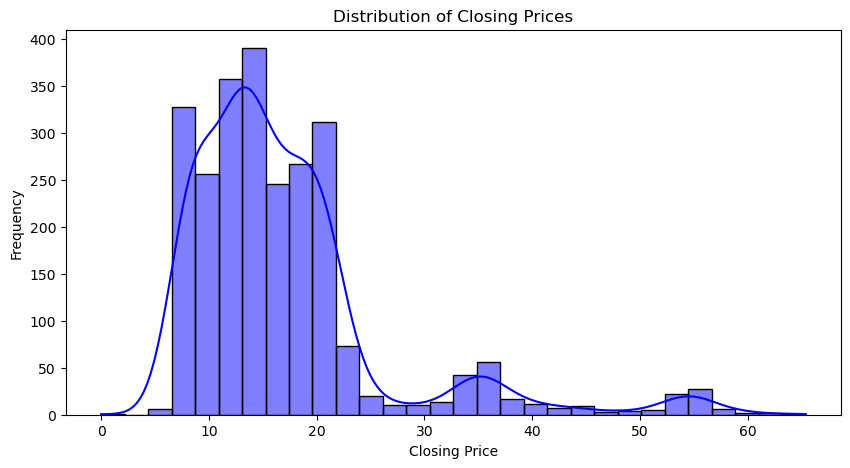

In [92]:
# 2. Phân tích thống kê cơ bản
print("Thống kê mô tả dữ liệu:")
print(data_vn.describe())
plt.figure(figsize=(10, 5))
sns.histplot(data_vn['close'], bins=30, kde=True, color='blue')
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()



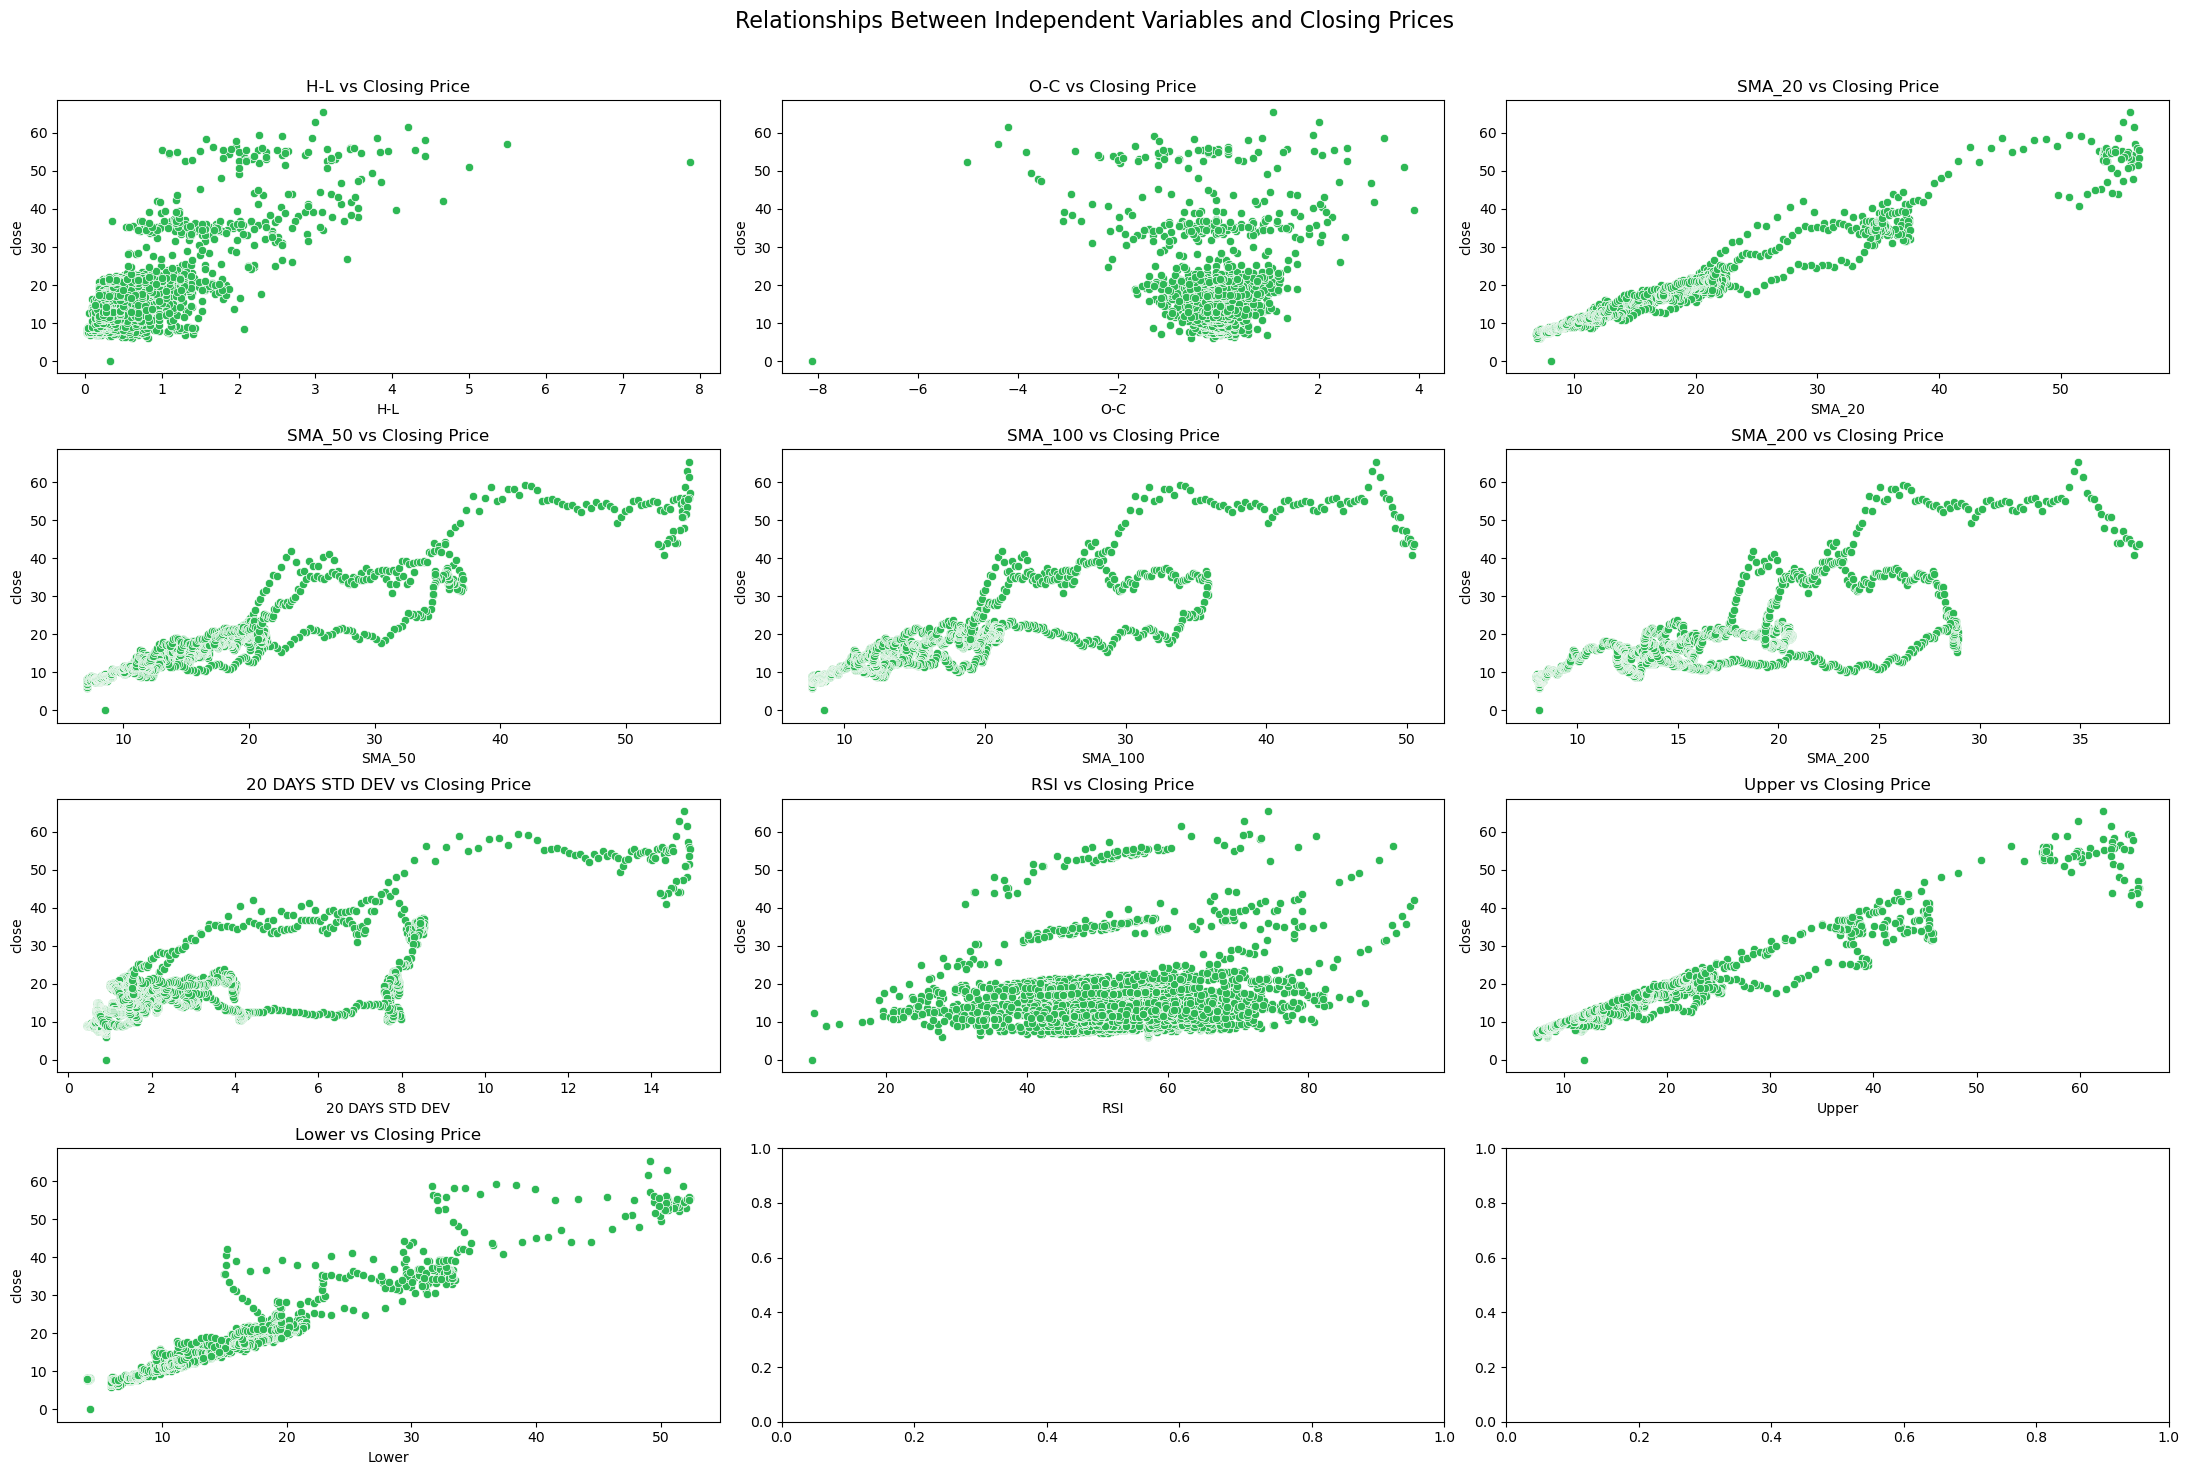

In [93]:
# 4. Kiểm tra mối quan hệ giữa các biến độc lập và biến phụ thuộc
fig, axes = plt.subplots(4, 3, figsize=(22, 15))
fig.suptitle('Relationships Between Independent Variables and Closing Prices', fontsize=16)


independent_vars = ['H-L', 'O-C', 'SMA_20','SMA_50', 'SMA_100', 'SMA_200', '20 DAYS STD DEV', 'RSI', 'Upper', 'Lower']
for idx, var in enumerate(independent_vars):
    row, col = divmod(idx, 3)
    sns.scatterplot(x=data_vn[var], y=data_vn['close'], ax=axes[row, col])
    axes[row, col].set_title(f'{var} vs Closing Price')


plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


# Tính toán hệ số tương quan để xác định độ mạnh của các mối quan hệ



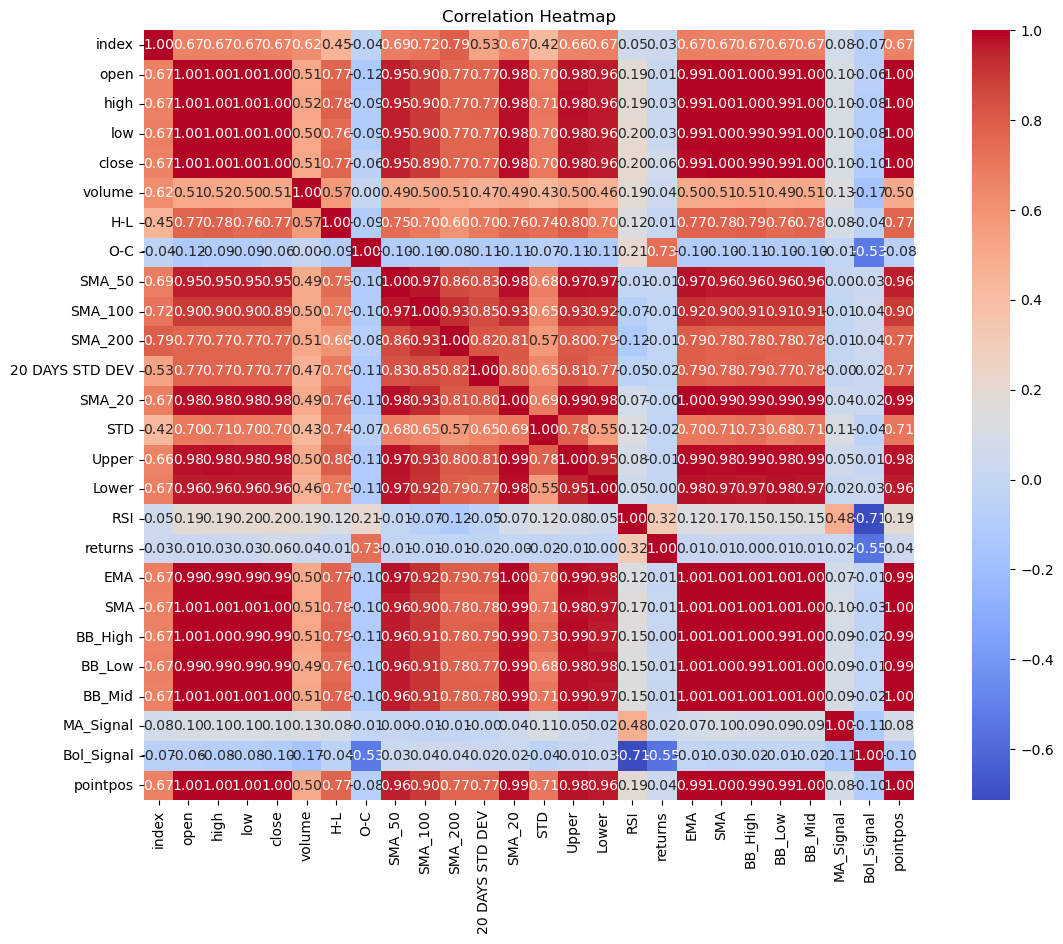

In [94]:
# 6. Cập nhật giả thuyết dựa trên hệ số tương quan
# Đưa ra các nhận xét và cập nhật giả thuyết:
# Drop 'IdNum' column and select only numeric data types
data_numeric = data_vn.select_dtypes(include=['int64', 'float64'])


# Calculate the correlation matrix
correlation_matrix = data_numeric.corr()

# Plot the correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar=True)
plt.title("Correlation Heatmap")
plt.show()



In [95]:
def check_outlier(x):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    q1 = np.percentile(x, 25, interpolation='midpoint')
    q3 = np.percentile(x, 75, interpolation='midpoint')

    # Calculate IQR
    iqr = q3 - q1

    # Calculate the upper and lower bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Identify outliers
    is_outlier = (x < lower_bound) | (x > upper_bound)

    # Return the boolean array indicating outliers
    return is_outlier


In [96]:
# Count the number of outliers in each column
outlier_counts = {
    'volume': np.sum(check_outlier(data_vn['volume'])),
    'H-L': np.sum(check_outlier(data_vn['H-L'])),
    'O-C': np.sum(check_outlier(data_vn['O-C'])),
    'SMA_50': np.sum(check_outlier(data_vn['SMA_50'])),
    'SMA_100': np.sum(check_outlier(data_vn['SMA_100'])),
    'SMA_200': np.sum(check_outlier(data_vn['SMA_200'])),
    '20 DAYS STD DEV': np.sum(check_outlier(data_vn['20 DAYS STD DEV'])),
    'RSI': np.sum(check_outlier(data_vn['RSI'])),
    'Upper': np.sum(check_outlier(data_vn['Upper'])),
    'Lower': np.sum(check_outlier(data_vn['Lower']))
}


# Display the counts of outliers
print("Count of outliers in each column:")
print(outlier_counts)

Count of outliers in each column:
{'volume': 91, 'H-L': 184, 'O-C': 344, 'SMA_50': 175, 'SMA_100': 127, 'SMA_200': 40, '20 DAYS STD DEV': 350, 'RSI': 24, 'Upper': 233, 'Lower': 170}


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10152\1827609034.py:3: DeprecationWarning:

the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10152\1827609034.py:4: DeprecationWarning:

the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10152\1827609034.py:5: DeprecationWarning:

the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)

C:\Users\ADMIN\AppData\Local\Te

# **LSTM**

## 4. Selection & Validation Model


In [97]:
# 1. Chọn đặc trưng (features) cho mô hình
features = ['close', 'SMA_50', 'SMA_100', 'SMA_200', '20 DAYS STD DEV', 'Upper', 'Lower','SMA_20']
dataset = data_vn[features].copy().dropna()

# 2. Chuẩn hóa toàn bộ dữ liệu (fit scaler trên DataFrame giữ nguyên cột)
scaler = StandardScaler()
dataset_scaled = scaler.fit_transform(dataset)

# 3. Chuẩn hóa riêng cột close để inverse transform sau
sc_close = StandardScaler()
close_scaled = sc_close.fit_transform(dataset[['close']])

In [98]:
# 4. Tạo chuỗi dữ liệu cho LSTM
def create_sequences(data, target_column, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(target_column[i])
    return np.array(X), np.array(y)

X, y = create_sequences(dataset_scaled, close_scaled, window_size=60)

# 5. Chia train/test
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [99]:
# 6. Xây dựng mô hình LSTM
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [100]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# Gọi EarlyStopping: dừng khi val_loss không giảm 10 epoch liên tiếp
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Gọi ModelCheckpoint: lưu mô hình tốt nhất theo val_loss
checkpoint = ModelCheckpoint(
    'best_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Huấn luyện
history = model.fit(
    X_train, y_train,
    epochs=100,  # số lớn để cho EarlyStopping tự dừng
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.1584
Epoch 1: val_loss improved from None to 0.04974, saving model to best_lstm_model.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - loss: 0.0817 - val_loss: 0.0497
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0283
Epoch 2: val_loss improved from 0.04974 to 0.03159, saving model to best_lstm_model.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0267 - val_loss: 0.0316
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0202
Epoch 3: val_loss improved from 0.03159 to 0.02719, saving model to best_lstm_model.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - loss: 0.0212 - val_loss: 0.0272
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0168
Epoch 4: val_loss improved from 0.02719 to 0.01839, saving model to best_lstm_model.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0169 - val_loss: 0.0184
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0194
Epoch 5: val_loss improved from 0.01839 to 0.01781, saving model to best_lstm_model.h5


...

55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0077 - val_loss: 0.0050
Epoch 70/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0077
Epoch 70: val_loss did not improve from 0.00504
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0074 - val_loss: 0.0055
Epoch 71/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0078
Epoch 71: val_loss improved from 0.00504 to 0.00496, saving model to best_lstm_model.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0079 - val_loss: 0.0050
Epoch 72/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0067
Epoch 72: val_loss improved from 0.00496 to 0.00484, saving model to best_lstm_model.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0066 - val_loss: 0.0048
Epoch 73/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0069
Epoch 73: val_loss did not improve from 0.00484
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0069 - val_loss: 0.0050
Epoch 74/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0070
Epoch 74: val_loss did not improve from 0.00484
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0076 - val_loss: 0.0051
Epoch 75/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0069
Epoch 75: val_loss improved from 0.00484 to 0.00476, saving model to best_lstm_model.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0069 - val_loss: 0.0048
Epoch 76/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0061
Epoch 76: val_loss did not improve from 0.00476
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0078 - val_loss: 0.0061
Epoch 77/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0062
Epoch 77: val_loss did not improve from 0.00476
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0065 - val_loss: 0.0049
Epoch 78/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0063
Epoch 78: val_loss did not improve from 0.00476
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0070 - val_loss: 0.0048
Epoch 79/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0061
Epoch 79: val_loss did not improve from 0.00476
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0072 - val_loss: 0.0052
Epoch 80/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0082
Epoch 80: val_loss improved from 0.00476 to 0.00454, saving model to best_lstm_model.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0083 - val_loss: 0.0045
Epoch 81/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0082
Epoch 81: val_loss did not improve from 0.00454
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0082 - val_loss: 0.0048
Epoch 82/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0071
Epoch 82: val_loss did not improve from 0.00454
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0070 - val_loss: 0.0050
Epoch 83/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0076
Epoch 83: val_loss did not improve from 0.00454
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0079 - val_loss: 0.0046
Epoch 84/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0069
Epoch 84: val_loss did not improve from 0.00454
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0066 - val_loss: 0.0050
Epoch 85/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0076
Epoch 85: val_loss did not improve from 0.00454
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 

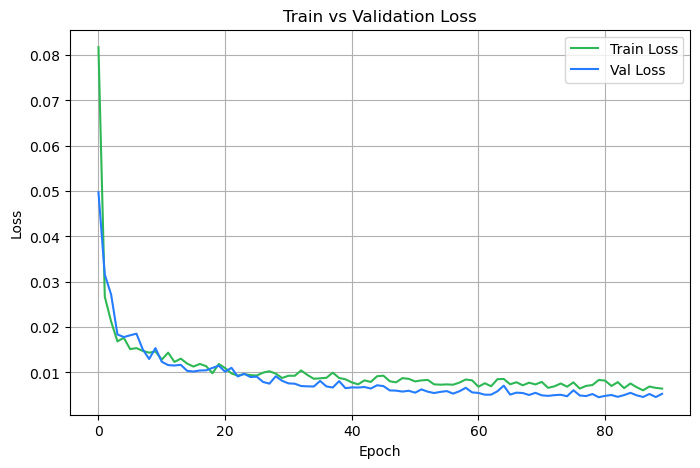

Epoch tốt nhất: 80
🔹 Val Loss nhỏ nhất: 0.004543


In [101]:
# Vẽ biểu đồ loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# In ra epoch tốt nhất
best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
val_losses = history.history['val_loss']
print(f"Epoch tốt nhất: {best_epoch}")
print(f"🔹 Val Loss nhỏ nhất: {val_losses[best_epoch-1]:.6f}")


In [102]:
history = model.fit(X_train, y_train, epochs=best_epoch, batch_size=32, validation_split=0.1)

Epoch 1/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - loss: 0.0082 - val_loss: 0.0045
Epoch 2/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - loss: 0.0065 - val_loss: 0.0045
Epoch 3/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - loss: 0.0069 - val_loss: 0.0048
Epoch 4/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - loss: 0.0077 - val_loss: 0.0059
Epoch 5/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0072 - val_loss: 0.0049
Epoch 6/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - loss: 0.0075 - val_loss: 0.0045
Epoch 7/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - loss: 0.0071 - val_loss: 0.0055
Epoch 8/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - loss: 0.0076 - val_loss: 0.0047
Epoch 9/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0078 - val_loss: 0.0057
Epoch 10/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - loss: 0.0076 - val_loss: 0.0047
Epoch 11/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0072 - val_loss: 0.0053
Epoch 12/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/ste

In [103]:
print("Ngày bắt đầu train:", data_vn['time'].iloc[60])  # vì window_size = 60
print("Ngày bắt đầu test :", data_vn['time'].iloc[split + 60])


Ngày bắt đầu train: 2016-01-20
Ngày bắt đầu test : 2023-11-24


In [104]:
# 2) Đánh giá trên tập test (1 lần duy nhất)
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred_test   = sc_close.inverse_transform(y_pred_scaled).reshape(-1)
y_true_test   = sc_close.inverse_transform(y_test).reshape(-1)

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
)
mse  = mean_squared_error(y_true_test, y_pred_test)
mae  = mean_absolute_error(y_true_test, y_pred_test)
r2   = r2_score(y_true_test, y_pred_test)
mape = mean_absolute_percentage_error(y_true_test, y_pred_test)
rmse = (mse ** 0.5)

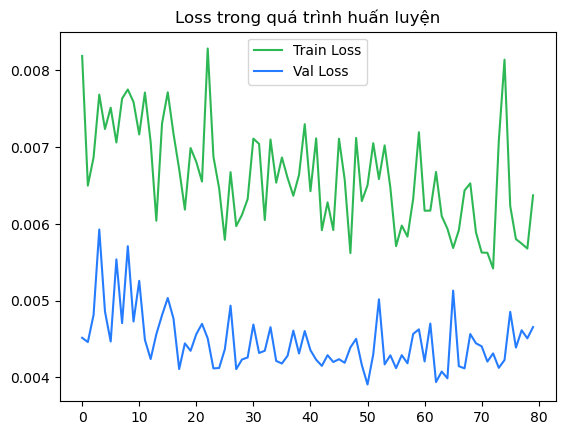

In [105]:
# Visual hóa loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss trong quá trình huấn luyện')
plt.show()


##5. Model Testing & Evaluation
Prompt: Viêt code python để Model Testing & Evaluation tạo ra những dự báo chính xác về giá cổ phiếu trong tương lai, đánh giá hiệu suất và Backtesting của các mô hình dự báo.

LSTM Model - MAPE: 5.7654%, R²: 0.8553, MSE: 23.5308, MAE: 2.4109, RMSE: 4.8509


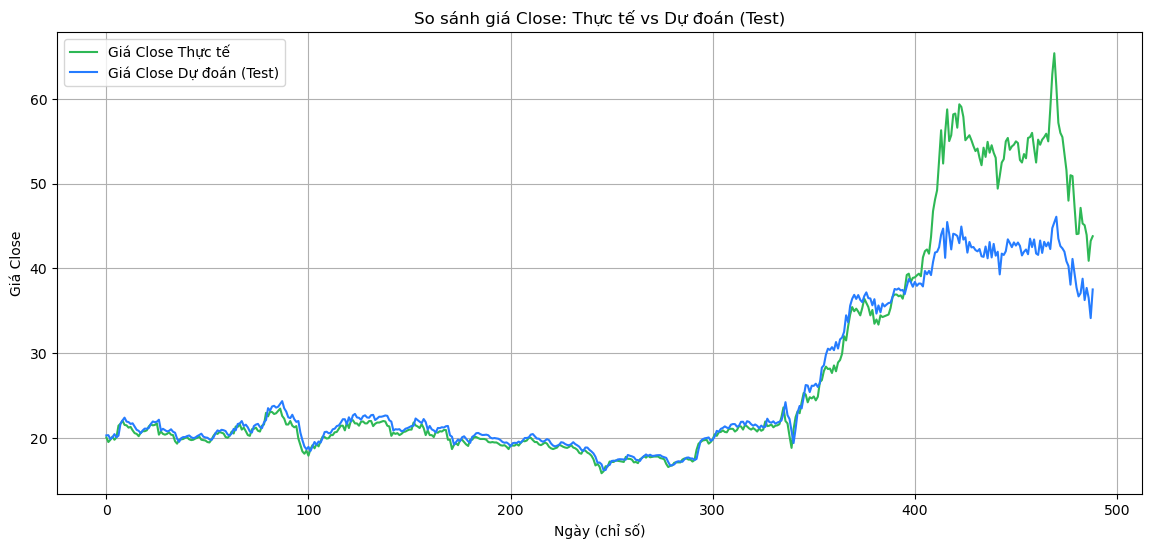

In [106]:
print(f"LSTM Model - MAPE: {mape:.4%}, R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# ==== VẼ SO SÁNH TRÊN TẬP TEST ====
plt.figure(figsize=(14,6))
plt.plot(y_true_test, label='Giá Close Thực tế')
plt.plot(y_pred_test, label='Giá Close Dự đoán (Test)')
plt.legend()
plt.title('So sánh giá Close: Thực tế vs Dự đoán (Test)')
plt.xlabel('Ngày (chỉ số)')
plt.ylabel('Giá Close')
plt.grid(True)
plt.show()

## **`Backtesting`**

LSTM Backtest - MSE: 31.3764, MAE: 3.0534, R²: 0.8415


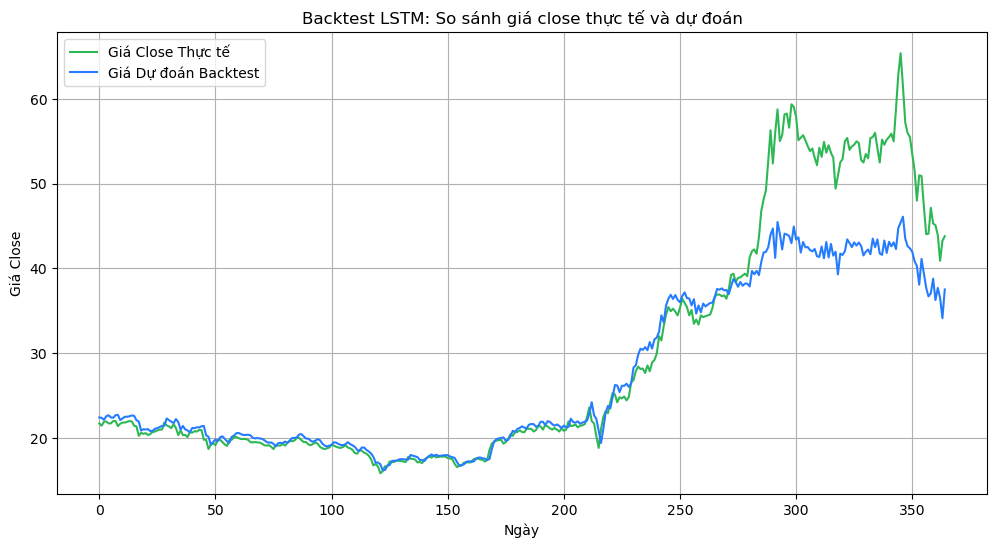

In [107]:
window_size = 60
backtest_period = 365

bt_true, bt_pred = [], []
for i in range(len(dataset_scaled) - backtest_period, len(dataset_scaled)):
    X_input = dataset_scaled[i - window_size:i]
    X_input = np.expand_dims(X_input, axis=0)
    pred_scaled = model.predict(X_input, verbose=0)
    pred = sc_close.inverse_transform(pred_scaled)[0,0]
    real = dataset['close'].iloc[i]
    bt_pred.append(pred); bt_true.append(real)

print(f"LSTM Backtest - MSE: {mean_squared_error(bt_true, bt_pred):.4f}, "
      f"MAE: {mean_absolute_error(bt_true, bt_pred):.4f}, "
      f"R²: {r2_score(bt_true, bt_pred):.4f}")

plt.figure(figsize=(12,6))
plt.plot(bt_true, label='Giá Close Thực tế')
plt.plot(bt_pred, label='Giá Dự đoán Backtest')
plt.title("Backtest LSTM: So sánh giá close thực tế và dự đoán")
plt.xlabel("Ngày"); plt.ylabel("Giá Close"); plt.legend(); plt.grid(True); plt.show()

# **Dự báo Tương lai**

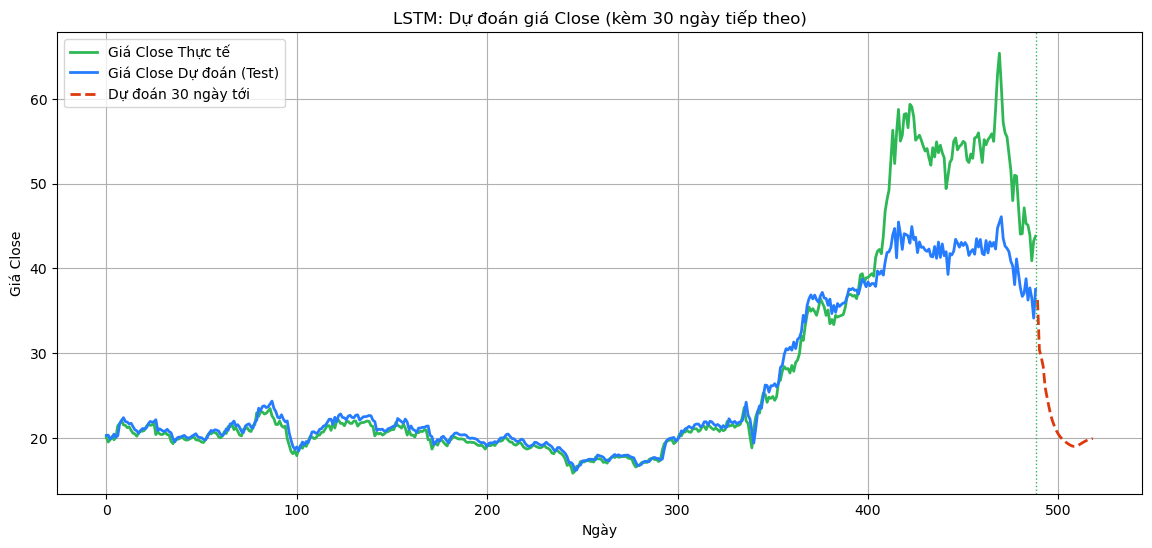

In [108]:
n_features  = dataset_scaled.shape[1]
target_col  = 0
last_window = dataset_scaled[-window_size:].copy()
future_scaled = []

for _ in range(30):
    x_in = last_window.reshape(1, window_size, n_features)
    next_scaled = model.predict(x_in, verbose=0)[0,0]
    future_scaled.append(next_scaled)
    new_step = last_window[-1].copy()
    new_step[target_col] = next_scaled
    last_window = np.vstack([last_window[1:], new_step])

future_30 = sc_close.inverse_transform(np.array(future_scaled).reshape(-1,1)).reshape(-1)

import pandas as pd
if isinstance(dataset.index, pd.DatetimeIndex):
    test_dates   = dataset.index[-len(y_true_test):]
    last_date    = dataset.index[-1]
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=len(future_30), freq='D')
else:
    test_dates   = np.arange(len(y_true_test))
    future_dates = np.arange(len(y_true_test), len(y_true_test) + len(future_30))

plt.figure(figsize=(14,6))
plt.plot(test_dates,   y_true_test, label='Giá Close Thực tế', linewidth=2)
plt.plot(test_dates,   y_pred_test, label='Giá Close Dự đoán (Test)', linewidth=2)
plt.plot(future_dates, future_30,    label='Dự đoán 30 ngày tới', linestyle='--', linewidth=2)  # màu mới mặc định
plt.axvline(x=test_dates[-1] if hasattr(test_dates, '__len__') else len(y_true_test), linestyle=':', linewidth=1)
plt.title('LSTM: Dự đoán giá Close (kèm 30 ngày tiếp theo)')
plt.xlabel('Ngày'); plt.ylabel('Giá Close'); plt.legend(); plt.grid(True); plt.show()

In [109]:
import numpy as np
import pandas as pd
from datetime import timedelta

def predict_next_close_lstm(date_str, data_vn, model, scaler, sc_close, window_size=60,
                            features=None):
    """
    Dự đoán giá close của NGÀY KẾ TIẾP so với ngày người dùng nhập (hoặc ngày gần nhất <= ngày nhập).

    Parameters
    ----------
    date_str : str          'YYYY-MM-DD'
    data_vn : pd.DataFrame  có cột 'time' và các features
    model : keras.Model     mô hình LSTM đã train
    scaler : fitted scaler  (StandardScaler/MinMaxScaler) dùng cho các features
    sc_close : fitted scaler cho cột 'close' (để inverse)
    window_size : int       số bước time-steps (mặc định 60)
    features : list[str]    danh sách cột features đã dùng khi train. Nếu None sẽ suy ra từ scaler
    """

    # 1) Chuẩn bị dữ liệu & ngày
    df = data_vn.copy()
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').reset_index(drop=True)

    input_date = pd.to_datetime(date_str).normalize()

    # Lấy bản ghi gần nhất <= ngày nhập
    upto = df[df['time'] <= input_date]
    if upto.empty:
        print(f"❌ Không có dữ liệu trước hoặc bằng ngày {input_date.date()}.")
        return None

    current_row = upto.iloc[-1]            # hàng gần nhất <= input_date
    current_day = current_row['time']

    print(f"\nℹ️ Dữ liệu tham chiếu: {current_day.date()} (gần nhất ≤ {input_date.date()})")
    print(f"- Open : {current_row['open']}")
    print(f"- Close: {current_row['close']}")
    print(f"- High : {current_row['high']}")
    print(f"- Low  : {current_row['low']}")

    # 2) Lấy đúng danh sách features theo scaler/đầu vào train
    if features is None:
        if hasattr(scaler, 'feature_names_in_'):
            features = list(scaler.feature_names_in_)
        else:
            # fallback: giả định bộ phổ biến bạn đang dùng
            features = ['close', 'SMA_50', 'SMA_100', 'SMA_200',
                        '20 DAYS STD DEV', 'Upper', 'Lower', 'SMA_20']

    # Bảo đảm các cột có mặt trong df
    missing_cols = [c for c in features if c not in df.columns]
    if missing_cols:
        print(f"❌ Thiếu cột trong dữ liệu: {missing_cols}")
        return None

    # 3) Lấy cửa sổ 60 ngày HỢP LỆ (không NaN ở các features)
    upto_feats = df.loc[df['time'] <= current_day, ['time'] + features].dropna()
    if len(upto_feats) < window_size:
        print(f"❌ Không đủ {window_size} ngày dữ liệu hợp lệ (đã loại NaN) để dự đoán.")
        return None

    # Lấy đúng thứ tự cột như lúc fit scaler
    cols = list(scaler.feature_names_in_) if hasattr(scaler, "feature_names_in_") else features

    seq_df = upto_feats.tail(window_size)[cols].astype(float)   # giữ DataFrame, có tên cột
    seq_scaled = scaler.transform(seq_df)                       # KHÔNG còn cảnh báo
    X_input = seq_scaled.reshape(1, window_size, len(cols))


    # 5) Dự đoán
    y_pred_scaled = model.predict(X_input, verbose=0).reshape(-1, 1)  # (1,1) -> (1,1)
    y_pred = float(sc_close.inverse_transform(y_pred_scaled)[0, 0])

    next_day = current_day + timedelta(days=1)
    print(f"\n✅ Dự đoán giá đóng cửa ngày {next_day.date()}: {y_pred:.2f} VND")

    return y_pred


In [110]:
d = input("Nhập ngày (YYYY-MM-DD): ").strip()
predict_next_close_lstm(d, data_vn, model, scaler, sc_close)



ℹ️ Dữ liệu tham chiếu: 2025-11-12 (gần nhất ≤ 2025-11-12)
- Open : 43.5
- Close: 43.8
- High : 44.1
- Low  : 42.9

✅ Dự đoán giá đóng cửa ngày 2025-11-13: 36.28 VND


36.27984619140625